<a href="https://colab.research.google.com/github/sam-wahid/vlm-llm-segmentation/blob/main/BenchmarkSAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q ultralytics
!pip install -q opencv-python matplotlib tqdm

  Preparing metadata (setup.py) ... done


In [8]:
import cv2
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [20]:
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms

# IMAGE TRANSFORM
image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# MASK TRANSFORM
mask_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.PILToTensor()
])

dataset = OxfordIIITPet(
    root="./data",
    split="test",
    target_types="segmentation",
    download=True,
    transform=image_transform,
    target_transform=mask_transform
)

# SMALL SUBSET
dataset = torch.utils.data.Subset(dataset, range(100))

loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=False
)

print("Total Images:", len(dataset))

Total Images: 100


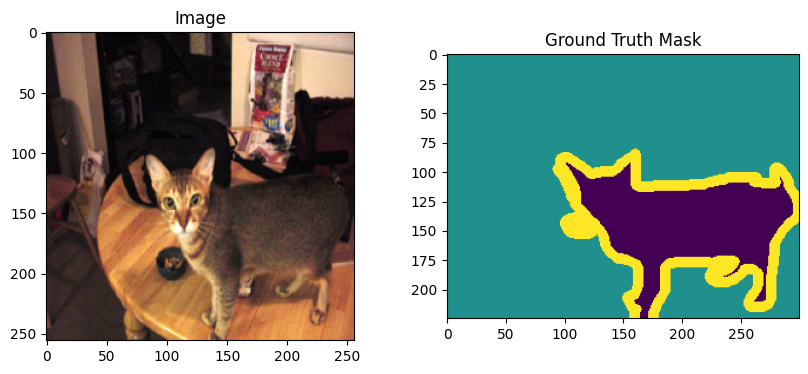

In [11]:
image, mask = dataset[0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0))
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Ground Truth Mask")

plt.show()

In [12]:
def compute_iou(pred, gt):

    pred = pred > 0
    gt = gt > 0

    intersection = np.logical_and(pred, gt).sum()

    union = np.logical_or(pred, gt).sum()

    if union == 0:
        return 0

    return intersection / union

In [13]:
def compute_dice(pred, gt):

    pred = pred > 0
    gt = gt > 0

    intersection = np.logical_and(pred, gt).sum()

    return (2 * intersection) / (
        pred.sum() + gt.sum() + 1e-8
    )

In [14]:
from ultralytics import SAM

mobile_sam = SAM("mobile_sam.pt")

print("MobileSAM Loaded")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
MobileSAM Loaded


In [25]:
def benchmark_model(model, loader, model_name):

    total_iou = 0
    total_dice = 0

    total_time = 0
    total_images = 0

    # RESET GPU MEMORY
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    for image, gt_mask in tqdm(loader):

        # IMAGE → NUMPY
        image_np = image[0].permute(1,2,0).numpy()
        image_np = (image_np * 255).astype(np.uint8)

        # GROUND TRUTH MASK
        gt_mask = gt_mask.squeeze().numpy()

        # START TIMER
        start = time.time()

        # MODEL PREDICTION
        results = model.predict(
            image_np,
            imgsz=256,
            verbose=False
        )

        # END TIMER
        end = time.time()

        total_time += (end - start)
        total_images += 1

        # HANDLE EMPTY PREDICTIONS
        try:
            pred_mask = results[0].masks.data[0].cpu().numpy()

        except:
            pred_mask = np.zeros_like(gt_mask)

        # CONVERT BOOL → UINT8
        pred_mask = pred_mask.astype(np.uint8)

        # RESIZE MASK
        pred_mask = cv2.resize(
            pred_mask,
            (gt_mask.shape[1], gt_mask.shape[0])
        )

        # BINARY MASKS
        pred_mask = pred_mask > 0
        gt_mask = gt_mask > 0

        # INTERSECTION
        intersection = np.logical_and(
            pred_mask,
            gt_mask
        ).sum()

        # UNION
        union = np.logical_or(
            pred_mask,
            gt_mask
        ).sum()

        # IoU
        iou = intersection / union if union != 0 else 0

        # DICE SCORE
        dice = (2 * intersection) / (
            pred_mask.sum() + gt_mask.sum() + 1e-8
        )

        total_iou += iou
        total_dice += dice

    # AVERAGE METRICS
    avg_iou = total_iou / total_images
    avg_dice = total_dice / total_images

    # SPEED METRICS
    fps = total_images / total_time
    latency = total_time / total_images

    # GPU MEMORY
    if torch.cuda.is_available():
        gpu_memory = (
            torch.cuda.max_memory_allocated() / 1024**3
        )
    else:
        gpu_memory = 0

    # PRINT RESULTS
    print(f"\n===== {model_name} RESULTS =====")

    print("IoU:", round(avg_iou, 4))
    print("Dice Score:", round(avg_dice, 4))
    print("FPS:", round(fps, 2))
    print("Latency:", round(latency, 4))
    print("GPU Memory:", round(gpu_memory, 2), "GB")

    # RETURN RESULTS
    return {
        "Model": model_name,
        "IoU": round(avg_iou, 4),
        "Dice": round(avg_dice, 4),
        "FPS": round(fps, 2),
        "Latency": round(latency, 4),
        "GPU Memory": round(gpu_memory, 2)
    }

In [26]:
from ultralytics import SAM

mobile_sam = SAM("mobile_sam.pt")

print("MobileSAM Loaded")

MobileSAM Loaded


In [27]:
mobile_results = benchmark_model(
    mobile_sam,
    loader,
    "MobileSAM"
)

100%|██████████| 100/100 [27:02<00:00, 16.22s/it]


===== MobileSAM RESULTS =====
IoU: 0.125
Dice Score: 0.1755
FPS: 0.06
Latency: 16.2016
GPU Memory: 0 GB


In [28]:
from ultralytics import FastSAM

fastsam_model = FastSAM("FastSAM-s.pt")

print("FastSAM Loaded")

FastSAM Loaded


In [29]:
fastsam_results = benchmark_model(
    fastsam_model,
    loader,
    "FastSAM"
)

100%|██████████| 100/100 [00:20<00:00,  4.96it/s]


===== FastSAM RESULTS =====
IoU: 0.3308
Dice Score: 0.4449
FPS: 5.33
Latency: 0.1875
GPU Memory: 0 GB


In [30]:
results = [
    mobile_results,
    fastsam_results
]

df = pd.DataFrame(results)

df

,Model,IoU,Dice,FPS,Latency,GPU Memory
0,MobileSAM,0.1250,0.1755,0.06,16.2016,0
1,FastSAM,0.3308,0.4449,5.33,0.1875,0


In [31]:
df.to_csv(
    "sam_benchmark_results.csv",
    index=False
)

print("CSV SAVED")

CSV SAVED


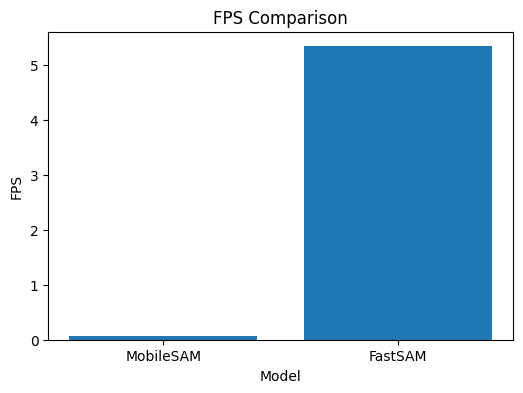

In [32]:
plt.figure(figsize=(6,4))

plt.bar(df["Model"], df["FPS"])

plt.xlabel("Model")
plt.ylabel("FPS")

plt.title("FPS Comparison")

plt.show()

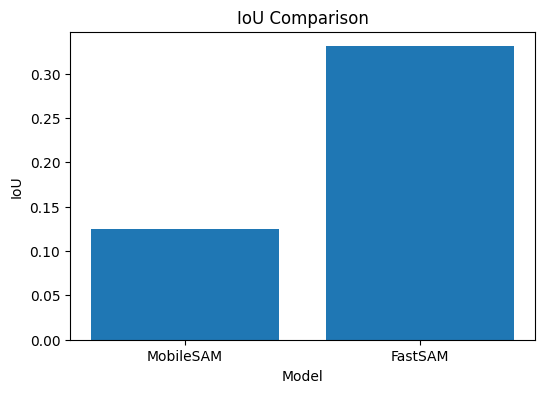

In [33]:
plt.figure(figsize=(6,4))

plt.bar(df["Model"], df["IoU"])

plt.xlabel("Model")
plt.ylabel("IoU")

plt.title("IoU Comparison")

plt.show()

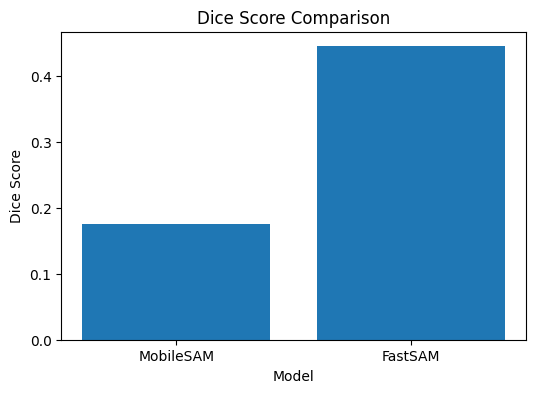

In [34]:
plt.figure(figsize=(6,4))

plt.bar(df["Model"], df["Dice"])

plt.xlabel("Model")
plt.ylabel("Dice Score")

plt.title("Dice Score Comparison")

plt.show()

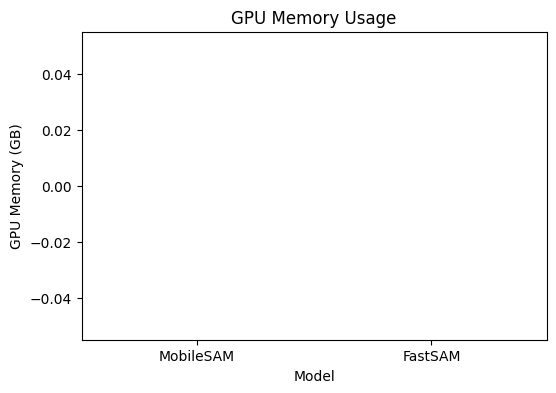

In [35]:
plt.figure(figsize=(6,4))

plt.bar(df["Model"], df["GPU Memory"])

plt.xlabel("Model")
plt.ylabel("GPU Memory (GB)")

plt.title("GPU Memory Usage")

plt.show()

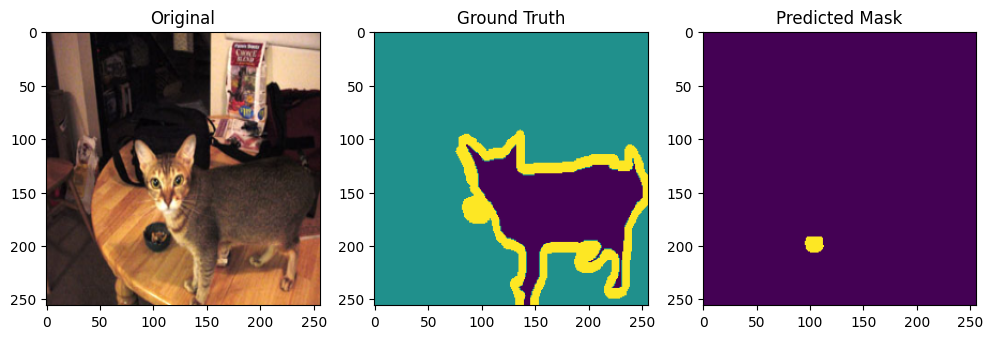

In [37]:
image, gt_mask = dataset[0]

# IMAGE
image_np = image.permute(1,2,0).numpy()
image_np = (image_np * 255).astype(np.uint8)

# REMOVE EXTRA DIMENSION
gt_mask = gt_mask.squeeze().numpy()

# PREDICTION
results = mobile_sam.predict(
    image_np,
    imgsz=256,
    verbose=False
)

pred_mask = results[0].masks.data[0].cpu().numpy()

# PLOT
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image_np)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(gt_mask)
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_mask)
plt.title("Predicted Mask")

plt.show()